In [1]:
import opendatasets as od

In [2]:
od.download("https://www.kaggle.com/datasets/shashanks1202/skin-cancer-dataset")

Skipping, found downloaded files in ".\skin-cancer-dataset" (use force=True to force download)


## Explore image dataset

In [3]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [4]:
DATA_DIR = "./skin-cancer-dataset/train_cancer/"

In [5]:
for data_dir, class_name, files in os.walk(DATA_DIR):
    print(f"Directory:{data_dir}\tClass:{class_name}\tNumber of images:{len(files)}")

Directory:./skin-cancer-dataset/train_cancer/	Class:['benign', 'malignant']	Number of images:0
Directory:./skin-cancer-dataset/train_cancer/benign	Class:[]	Number of images:30
Directory:./skin-cancer-dataset/train_cancer/malignant	Class:[]	Number of images:240



    Image dtype:uint8
    Image min/max value : 5/240
    Image shape: (224, 224, 3)



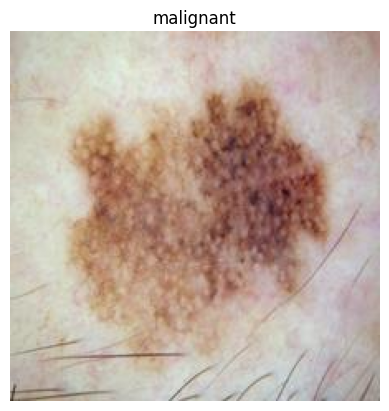

In [6]:
random_class = random.choice(os.listdir(DATA_DIR))
random_img = random.choice(os.listdir(os.path.join(DATA_DIR, random_class)))
img = mpimg.imread(os.path.join(DATA_DIR, random_class,random_img))

print(f"""
    Image dtype:{img.dtype}
    Image min/max value : {img.min()}/{img.max()}
    Image shape: {img.shape}
""")
plt.title(random_class)
plt.imshow(img)
plt.axis(False)
plt.show()

## Load image dataset using TensorFlow 

In [7]:
import tensorflow as tf


In [8]:
train_data, test_data = tf.keras.preprocessing.image_dataset_from_directory(DATA_DIR,
                                                                            batch_size=None,
                                                                            image_size=(224,224),
                                                                            shuffle=True,
                                                                            seed=42,
                                                                            validation_split=0.25,
                                                                            subset="both")

Found 270 files belonging to 2 classes.
Using 203 files for training.
Using 67 files for validation.


## Preprocessing images

In [9]:
def preprocessImage(image, label):
    return tf.cast(image, tf.float32), label

In [10]:
train_data = train_data.map(map_func=preprocessImage, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.map(map_func=preprocessImage, num_parallel_calls=tf.data.AUTOTUNE)

In [11]:
train_data, test_data

(<ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>,
 <ParallelMapDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int32, name=None))>)

# Batching data

In [12]:
train_data = train_data.batch(8).prefetch(tf.data.AUTOTUNE)
test_data = test_data.batch(8).prefetch(tf.data.AUTOTUNE)

## Constructing a model with transfer learning

In [13]:
from tensorflow.keras import layers

In [14]:
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top=False)
base_model.trainable=False # freeze all model's layers

In [15]:
# Building a model with Functional API
inputs = layers.Input(shape=(224,224,3), dtype=tf.float32, name="input_layer")
x = base_model(inputs, training=False)#sets model in inference mode
x = layers.GlobalAveragePooling2D(name="poolingLayer")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output_layer")(x)
model = tf.keras.Model(inputs, outputs, name="efficientNetB0")

In [16]:
model.summary()

Model: "efficientNetB0"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b0 (Function  (None, None, None, 1280)  5919312  
 al)                                                             
                                                                 
 poolingLayer (GlobalAverage  (None, 1280)             0         
 Pooling2D)                                                      
                                                                 
 output_layer (Dense)        (None, 1)                 1281      
                                                                 
Total params: 5,920,593
Trainable params: 1,281
Non-trainable params: 5,919,312
_________________________________________________________________


In [17]:
##compiling the model
model.compile(loss="binary_crossentropy", 
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [18]:
## Fitting the model
model_history = model.fit(train_data,
                          epochs=5,
                          steps_per_epoch=len(train_data),
                          validation_data=test_data,
                          validation_steps=int(0.15 * len(test_data))) ## validates only on 15% of the test data

Epoch 1/5
26/26 [==============================] - 9s 76ms/step - loss: 0.3942 - accuracy: 0.8719 - val_loss: 0.2912 - val_accuracy: 0.8750
Epoch 2/5
26/26 [==============================] - 0s 16ms/step - loss: 0.2408 - accuracy: 0.8916 - val_loss: 0.2221 - val_accuracy: 0.8750
Epoch 3/5
26/26 [==============================] - 0s 17ms/step - loss: 0.1999 - accuracy: 0.9360 - val_loss: 0.1869 - val_accuracy: 0.8750
Epoch 4/5
26/26 [==============================] - 0s 16ms/step - loss: 0.1650 - accuracy: 0.9458 - val_loss: 0.1710 - val_accuracy: 0.8750
Epoch 5/5
26/26 [==============================] - 0s 17ms/step - loss: 0.1460 - accuracy: 0.9606 - val_loss: 0.1591 - val_accuracy: 0.8750


## Evaluating the model 

In [19]:
model.evaluate(test_data)

9/9 [==============================] - 0s 15ms/step - loss: 0.1817 - accuracy: 0.9403


[0.18166044354438782, 0.9402984976768494]

## Trying to optimize the results- FINE-TUNE

In [20]:
base_model.trainable=True #Unfreezing all the model's layers

In [21]:
## compiling the model again
##compiling the model
model.compile(loss="binary_crossentropy", 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # lr 10x less
              metrics=["accuracy"])

In [22]:
## callback to save best performing model
def createModelCheckpoint(path="Model/Experiments", model_name=None):
    return tf.keras.callbacks.ModelCheckpoint(filepath=f'./{path}/{model_name}',
                                              save_best_only=True)

In [23]:
path = "ModelExperiment"

In [24]:
model_history_fineTune = model.fit(train_data,
                                   epochs=10,
                                   initial_epoch=model_history.epoch[-1],
                                   callbacks=[createModelCheckpoint(path,model.name)],
                                   steps_per_epoch=len(train_data),
                                   validation_data=test_data,
                                   validation_steps=int(0.15 * len(test_data))) ## validates only on 15% of the test data

Epoch 5/10
26/26 [==============================] - ETA: 0s - loss: 0.1791 - accuracy: 0.9360

INFO:tensorflow:Assets written to: ./ModelExperiment\efficientNetB0\assets


INFO:tensorflow:Assets written to: ./ModelExperiment\efficientNetB0\assets


26/26 [==============================] - 45s 1s/step - loss: 0.1791 - accuracy: 0.9360 - val_loss: 0.2081 - val_accuracy: 0.8750
Epoch 6/10
26/26 [==============================] - 2s 50ms/step - loss: 0.0286 - accuracy: 0.9951 - val_loss: 0.3548 - val_accuracy: 0.8750
Epoch 7/10
26/26 [==============================] - 1s 48ms/step - loss: 0.0087 - accuracy: 1.0000 - val_loss: 0.2804 - val_accuracy: 0.8750
Epoch 8/10
26/26 [==============================] - 1s 48ms/step - loss: 0.0016 - accuracy: 1.0000 - val_loss: 0.6910 - val_accuracy: 0.8750
Epoch 9/10
26/26 [==============================] - 1s 52ms/step - loss: 7.7314e-04 - accuracy: 1.0000 - val_loss: 0.4055 - val_accuracy: 0.8750
Epoch 10/10
26/26 [==============================] - 1s 51ms/step - loss: 3.8143e-04 - accuracy: 1.0000 - val_loss: 0.3902 - val_accuracy: 0.8750


## Loading and evaluating the best performing model

In [26]:
## Loading best performing model
model=tf.keras.models.load_model("./ModelExperiment/efficientNetB0/")

In [27]:
## evaluating
model.evaluate(test_data)

9/9 [==============================] - 2s 18ms/step - loss: 0.1922 - accuracy: 0.9552


[0.1922311931848526, 0.9552238583564758]